# Bài tập Buổi 8 — Cây Quyết Định & Rừng Ngẫu Nhiên (Decision Tree & Random Forest)

**Sinh viên thực hiện:** Phú Thành

---

## Bối cảnh

Trong bài tập này, bạn đang đóng vai trò là một Data Scientist làm việc tại một trung tâm nghiên cứu ung thư. Bạn được giao nhiệm vụ phân tích bộ dữ liệu **Breast Cancer Wisconsin (Diagnostic)**, chứa các thông số đo lường từ hình ảnh sinh thiết tế bào của các bệnh nhân.

Mục tiêu của bài toán là xây dựng mô hình học máy để phân loại khối u là **Lành tính (Benign)** hay **Ác tính (Malignant)**.

**Lưu ý quan trọng:** Trong bài toán chẩn đoán ung thư, việc chẩn đoán sót một khối u ác tính thành lành tính (False Negative) mang lại hậu quả nghiêm trọng hơn rất nhiều so với việc chẩn đoán nhầm lành tính thành ác tính (False Positive). Do đó, chúng ta sẽ đặc biệt quan tâm đến chỉ số **Recall**.

## Mục tiêu bài tập

1. Hiểu và xử lý bộ dữ liệu y khoa cơ bản với nhiều đặc trưng dạng số liên tục.
2. Huấn luyện mô hình **Decision Tree** và trực quan hóa các ranh giới quyết định (Decision Boundaries) thông qua cấu trúc cây.
3. Xây dựng mô hình **Random Forest** và đánh giá độ quan trọng của các đặc trưng (Feature Importance) trong việc chẩn đoán.
4. Phân tích chuyên sâu về các độ đo **Recall, F1-Score** và **Confusion Matrix** thay vì chỉ phụ thuộc vào Accuracy.

## Tiêu chí chấm (10 điểm)

| Task | Nội dung | Điểm |
|---|---|---|
| **1** | EDA & Thống kê dữ liệu tổng quan | 1.0 |
| **2** | Trực quan hóa tương quan dữ liệu | 2.0 |
| **3** | Chia tập & Scaling | 1.0 |
| **4** | Huấn luyện Decision Tree & Trực quan hóa cây | 2.0 |
| **5** | Huấn luyện Random Forest & Feature Importance | 2.0 |
| **6** | Đánh giá Confusion Matrix, Recall, F1-score và rút ra Insight | 2.0 |

---


## 0. Chuẩn bị môi trường & Nạp dữ liệu

Dữ liệu được tích hợp sẵn trong thư viện `scikit-learn`. Chạy ô bên dưới để tải và hiển thị.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, f1_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)

# Tải dữ liệu Breast Cancer
cancer_data = load_breast_cancer()
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df['target'] = cancer_data.target

print("Kích thước bộ dữ liệu:", df.shape)
print("Ý nghĩa Target (0: Malignant/Ác tính, 1: Benign/Lành tính):")
print(dict(zip(range(len(cancer_data.target_names)), cancer_data.target_names)))
df.head()

Kích thước bộ dữ liệu: (569, 31)
Ý nghĩa Target (0: Malignant/Ác tính, 1: Benign/Lành tính):
{0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


---
## Task 1 — EDA và Kiểm tra Dữ liệu Cơ Bản

### Yêu cầu:
1. In ra số lượng mẫu dữ liệu cho từng lớp (0: Ác tính, 1: Lành tính) bằng `value_counts()`.
2. Kiểm tra xem dữ liệu có giá trị khuyết thiếu (NaN) nào không.
3. Nêu nhận xét về sự cân bằng của bộ dữ liệu.

### Gợi ý:
- Sử dụng cú pháp `df['tên_cột'].value_counts()` để đếm số lượng nhãn.
- Để kiểm tra missing value trên toàn bộ dataframe, bạn có thể kết hợp `.isnull().sum()`.

In [2]:
# TODO 1a: Đếm số lượng mẫu của từng class trong cột 'target'
print("Số lượng mẫu mỗi lớp (0 = Ác tính/Malignant, 1 = Lành tính/Benign):")
print(df["target"].value_counts().sort_index())
print("\nTỷ lệ mỗi lớp:")
print(df["target"].value_counts(normalize=True).sort_index().round(4))

# TODO 1b: Kiểm tra giá trị missing
print("\nTổng số giá trị missing trên toàn bộ dataframe:", df.isnull().sum().sum())

Số lượng mẫu mỗi lớp (0 = Ác tính/Malignant, 1 = Lành tính/Benign):
target
0    212
1    357
Name: count, dtype: int64

Tỷ lệ mỗi lớp:
target
0    0.3726
1    0.6274
Name: proportion, dtype: float64

Tổng số giá trị missing trên toàn bộ dataframe: 0


**Nhận xét Task 1:**

- Bộ dữ liệu có **569 mẫu**, phân bố: **212 mẫu Ác tính (lớp 0, ~37%)** và **357 mẫu Lành tính (lớp 1, ~63%)**.
- Đây là mức **mất cân bằng nhẹ** (tỷ lệ ~37/63), chưa nghiêm trọng nhưng đủ để lưu ý rằng **Accuracy đơn thuần có thể gây hiểu lầm** — cần nhìn thêm Recall/F1 cho lớp Ác tính (lớp thiểu số nhưng quan trọng nhất về mặt y khoa).
- **Không có giá trị missing** (tổng = 0), nên không cần bước điền khuyết thiếu.

---
## Task 2 — Trực quan hóa Dữ liệu Y khoa

Bộ dữ liệu có tới 30 đặc trưng, chúng ta sẽ khảo sát một vài đặc trưng cơ bản.

### Yêu cầu:
1. Vẽ biểu đồ **Boxplot** so sánh phân phối của biến `mean radius` (bán kính trung bình của tế bào) giữa 2 lớp Khối u (Ác tính và Lành tính).
2. Vẽ biểu đồ **Scatter plot** giữa `mean radius` (trục x) và `mean texture` (trục y), tô màu (hue) theo cột `target`.
3. Có thể dùng 2 đặc trưng này để phân định ranh giới cơ bản giữa khối u lành/ác được không? Vì sao?

### Gợi ý:
- Vẽ Boxplot: `sns.boxplot(data=df, x='target', y='mean radius')`.
- Vẽ Scatter plot: `sns.scatterplot(data=df, x='mean radius', y='mean texture', hue='target')`.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4168\2421740579.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Ác tính (0)", "Lành tính (1)"])


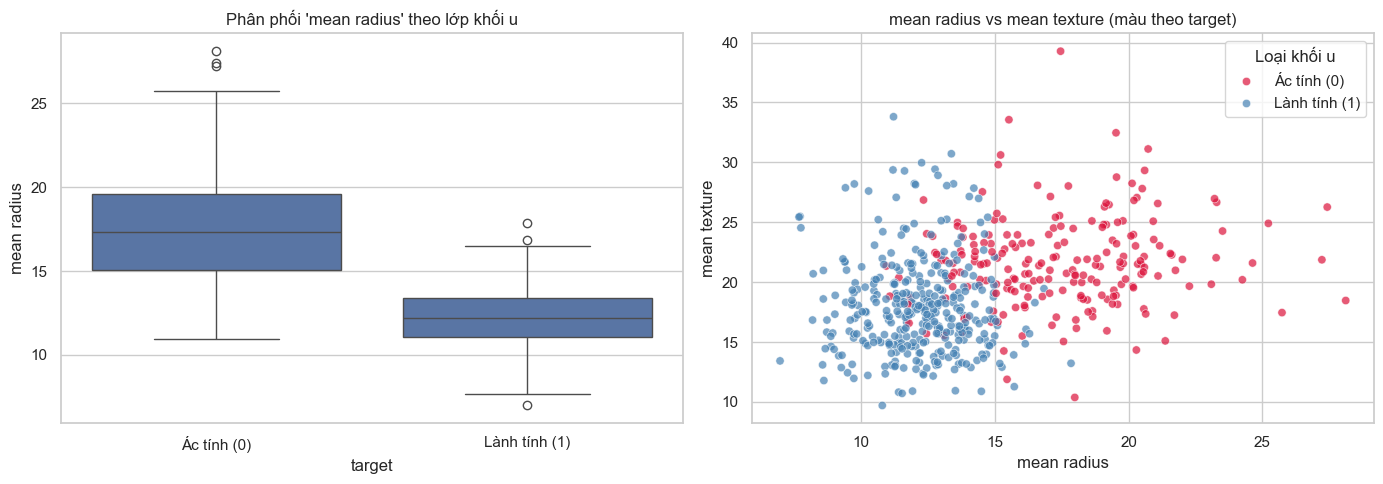

In [3]:
# TODO 2a: Boxplot cho biến 'mean radius' so với 'target'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="target", y="mean radius", ax=axes[0])
axes[0].set_title("Phân phối 'mean radius' theo lớp khối u")
axes[0].set_xticklabels(["Ác tính (0)", "Lành tính (1)"])

# TODO 2b: Scatter plot giữa 'mean radius' và 'mean texture'
sns.scatterplot(data=df, x="mean radius", y="mean texture", hue="target",
                palette={0: "crimson", 1: "steelblue"}, alpha=0.7, ax=axes[1])
axes[1].set_title("mean radius vs mean texture (màu theo target)")
handles, _ = axes[1].get_legend_handles_labels()
axes[1].legend(handles, ["Ác tính (0)", "Lành tính (1)"], title="Loại khối u")
plt.tight_layout()
plt.show()

**Nhận xét Task 2:**

- **Boxplot:** khối u **Ác tính (0)** có `mean radius` **lớn hơn rõ rệt** (trung vị ~17–19) so với **Lành tính (1)** (trung vị ~12). Hai hộp gần như tách biệt → `mean radius` là đặc trưng phân biệt rất tốt.
- **Scatter plot:** dùng `mean radius` + `mean texture` đã cho thấy **hai lớp phân tách khá rõ**: các điểm Ác tính (đỏ) dồn về phía bán kính lớn, Lành tính (xanh) về phía bán kính nhỏ.
- **Trả lời câu hỏi:** Có thể phân định ranh giới **cơ bản** bằng 2 đặc trưng này, nhưng **chưa hoàn hảo** — vẫn có **vùng chồng lấn** ở khoảng bán kính trung bình (~13–16), nơi các điểm hai màu trộn lẫn. Vì vậy cần **nhiều đặc trưng hơn** (bộ có tới 30 đặc trưng) và mô hình mạnh hơn (Random Forest) để phân loại chính xác vùng ranh giới này.

---
## Task 3 — Chia Tập Dữ Liệu và Tiền Xử Lý

### Yêu cầu:
1. Tách đặc trưng (X) và nhãn (y).
2. Chia tập Train/Test theo tỷ lệ **75/25**, `stratify=y`, và `random_state=42`.
3. Mặc dù Decision Tree và Random Forest không yêu cầu chuẩn hóa (Scaling), nhưng việc có `StandardScaler` sẽ giúp dễ dàng so sánh với các thuật toán khác (như SVM/Logistic Regression) sau này. Hãy fit `StandardScaler` trên `X_train` và transform cho cả `X_train` và `X_test`.

### Gợi ý:
- Sử dụng hàm `train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)`.
- **Nguyên tắc chống Data Leakage:** Chỉ dùng phương thức `.fit_transform()` trên tập `X_train`, nhưng chỉ được dùng phương thức `.transform()` trên tập `X_test`.

In [4]:
# TODO 3a: Tách X, y và chia train/test
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Tỷ lệ lớp - train:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Tỷ lệ lớp - test :", y_test.value_counts(normalize=True).round(3).to_dict())

# TODO 3b: Chuẩn hóa dữ liệu bằng StandardScaler (fit chỉ trên train -> chống leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("\nĐã scale xong. Kiểm tra train: mean ≈", round(X_train_scaled.mean(), 3),
      ", std ≈", round(X_train_scaled.std(), 3))

Train: (426, 30) | Test: (143, 30)
Tỷ lệ lớp - train: {1: 0.627, 0: 0.373}
Tỷ lệ lớp - test : {1: 0.629, 0: 0.371}

Đã scale xong. Kiểm tra train: mean ≈ -0.0 , std ≈ 1.0


---
## Task 4 — Huấn luyện Cây Quyết Định (Decision Tree)

### Yêu cầu:
1. Khởi tạo và huấn luyện `DecisionTreeClassifier(max_depth=3, random_state=42)` trên tập Train.
2. Sử dụng `plot_tree` để vẽ cấu trúc cây.
3. Nút gốc (Root Node) đang dùng đặc trưng nào để chia nhánh dữ liệu đầu tiên? Bạn có nghĩ đó là đặc trưng quan trọng nhất không?

### Gợi ý:
- Khởi tạo mô hình: `dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)`.
- Đừng quên gọi `.fit(X_train_scaled, y_train)` trước khi thực hiện vẽ sơ đồ cây.

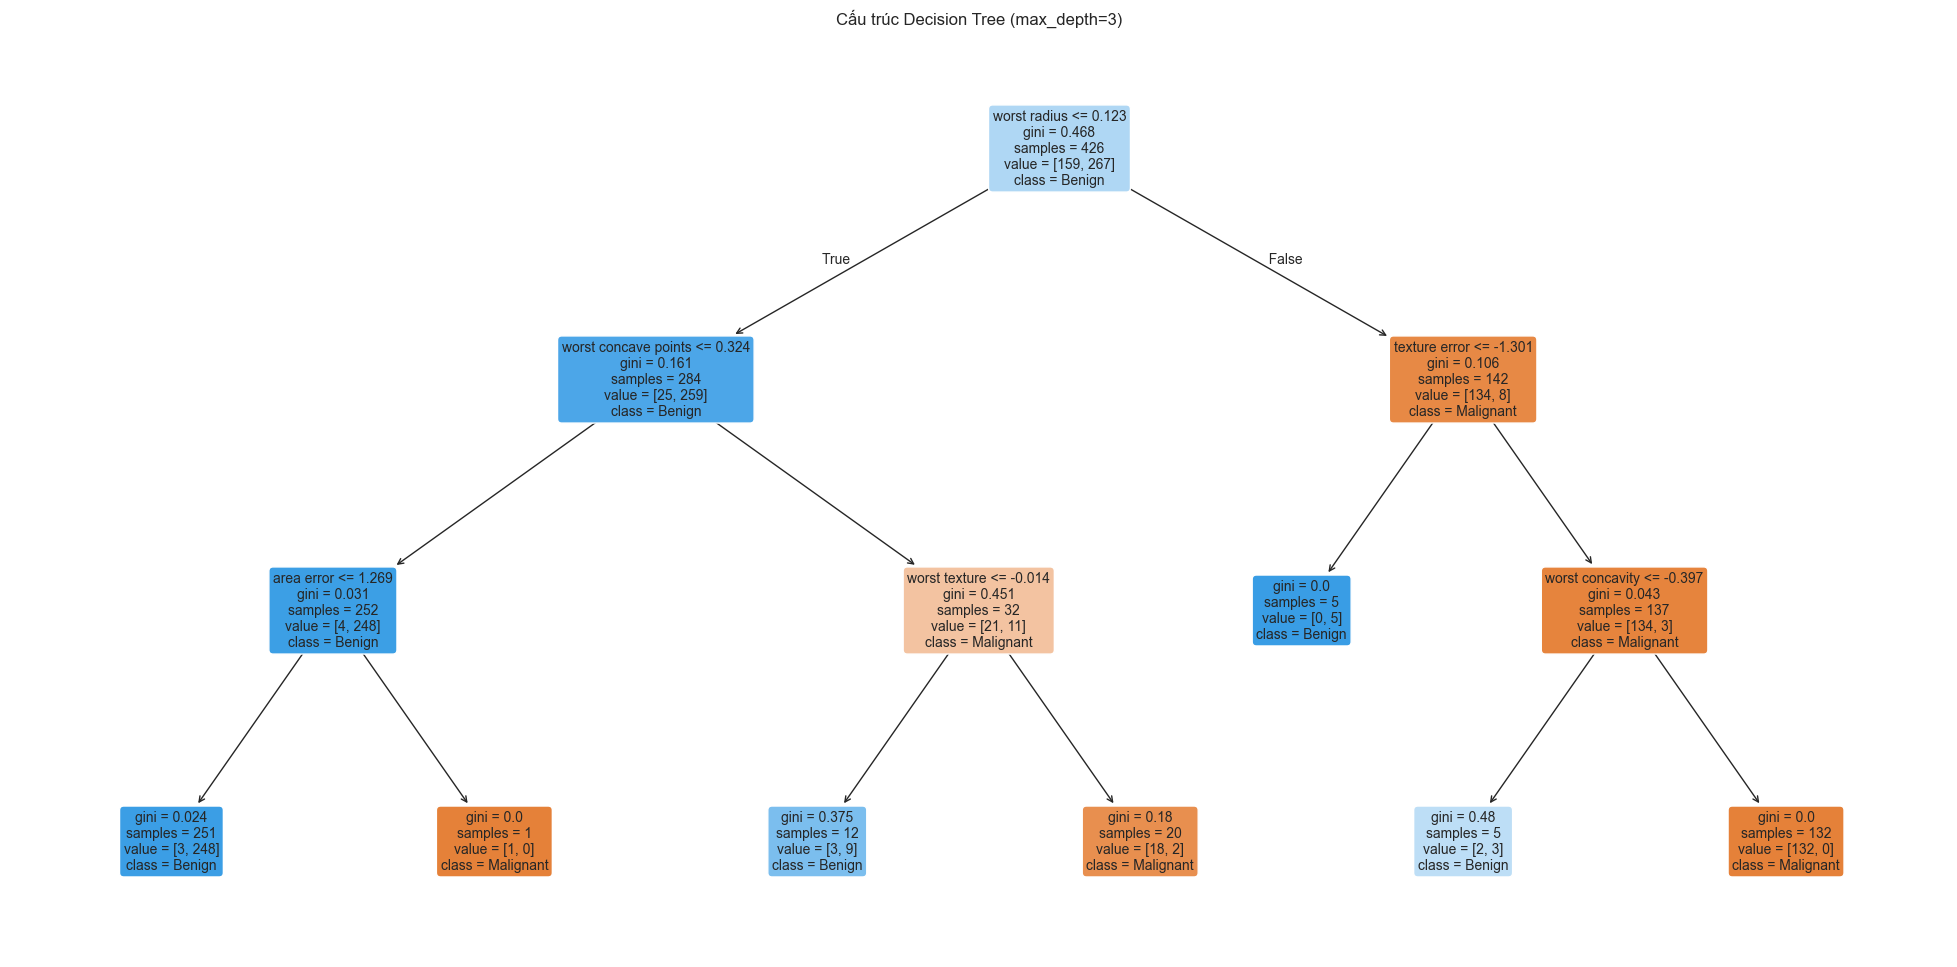

Đặc trưng phân nhánh tại nút gốc: worst radius


In [5]:
# TODO 4a: Khởi tạo và huấn luyện Decision Tree
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train_scaled, y_train)

# TODO 4b: Vẽ cấu trúc Decision Tree
plt.figure(figsize=(25, 12))
plot_tree(dt_model, feature_names=cancer_data.feature_names,
          class_names=["Malignant", "Benign"], filled=True, rounded=True, fontsize=10)
plt.title("Cấu trúc Decision Tree (max_depth=3)")
plt.show()

# In đặc trưng ở nút gốc để nhận xét chính xác
root_feat = cancer_data.feature_names[dt_model.tree_.feature[0]]
print("Đặc trưng phân nhánh tại nút gốc:", root_feat)

**Nhận xét Task 4:**

- Nút gốc (Root Node) phân nhánh đầu tiên theo đặc trưng **`worst radius`** (bán kính lớn nhất đo được của tế bào) — đây là biến tách hai lớp tốt nhất trên toàn tập train.
- Đây **rất có khả năng là một trong những đặc trưng quan trọng nhất**: Decision Tree chọn biến chia ở nút gốc là biến làm **giảm impurity (Gini) nhiều nhất**. `worst radius` phản ánh trực tiếp kích thước bất thường của khối u — khối u ác tính thường lớn hơn — nên rất hợp lý khi nó dẫn dắt quyết định đầu tiên.
- Tuy nhiên "quan trọng ở nút gốc của 1 cây" chưa chắc là quan trọng nhất tổng thể — ta sẽ kiểm chứng bằng **Feature Importance của Random Forest** ở Task 5 (trung bình trên 100 cây, ổn định hơn). Thực tế `worst radius` cùng nhóm `worst perimeter`, `worst area`, `worst concave points` đều nằm trong Top đặc trưng quan trọng.

---
## Task 5 — Rừng Ngẫu Nhiên & Độ Quan Trọng của Đặc Trưng

### Yêu cầu:
1. Khởi tạo và huấn luyện `RandomForestClassifier(n_estimators=100, random_state=42)`.
2. Lấy ra mức độ quan trọng của từng đặc trưng (`feature_importances_`).
3. Vẽ biểu đồ **Bar plot ngang (Horizontal Barplot)** hiển thị **Top 10 đặc trưng quan trọng nhất** theo đánh giá của Random Forest.

### Gợi ý:
- Tạo DataFrame để dễ dàng sắp xếp: `imp_df = pd.DataFrame({'Feature': cancer_data.feature_names, 'Importance': rf_model.feature_importances_})`.
- Sắp xếp giảm dần: `imp_df = imp_df.sort_values(by='Importance', ascending=False)`.
- Lấy 10 dòng đầu (`.head(10)`) và đưa vào hàm `sns.barplot(data=..., x='Importance', y='Feature')` để vẽ.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4168\1771079096.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x="Importance", y="Feature", palette="viridis")


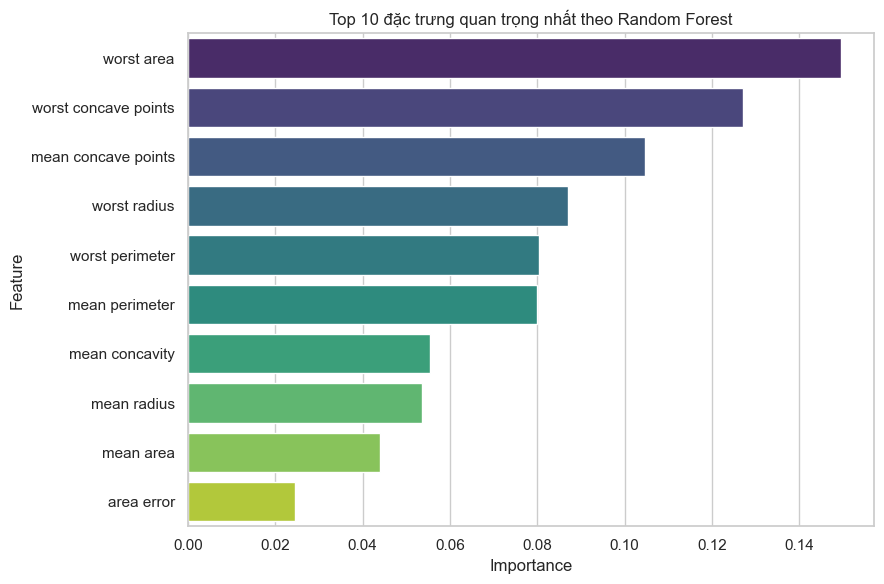

Top 10 Feature Importance:


,Feature,Importance
0,worst area,0.149674
1,worst concave points,0.127189
2,mean concave points,0.104650
3,worst radius,0.086963
4,worst perimeter,0.080299
5,mean perimeter,0.080037
6,mean concavity,0.055420
7,mean radius,0.053665
8,mean area,0.044062
9,area error,0.024557


In [6]:
# TODO 5a: Huấn luyện Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# TODO 5b: Trích xuất và trực quan hóa Top 10 Feature Importances
imp_df = pd.DataFrame({
    "Feature": cancer_data.feature_names,
    "Importance": rf_model.feature_importances_,
}).sort_values(by="Importance", ascending=False)

top10 = imp_df.head(10)
plt.figure(figsize=(9, 6))
sns.barplot(data=top10, x="Importance", y="Feature", palette="viridis")
plt.title("Top 10 đặc trưng quan trọng nhất theo Random Forest")
plt.tight_layout()
plt.show()

print("Top 10 Feature Importance:")
display(top10.reset_index(drop=True))

---
## Task 6 — Đánh giá Mô Hình chuyên sâu (Confusion Matrix, Recall, F1)

Trong bài toán này:
*   **Class 0 (Malignant - Ác tính)** là lớp chúng ta cực kỳ muốn tìm ra.
*   **Class 1 (Benign - Lành tính)** là lớp ít nguy hiểm hơn.

**Recall của lớp 0** cho biết: Trong tổng số những người thực sự mắc bệnh ung thư ác tính, mô hình đã "bắt" được bao nhiêu phần trăm?

### Yêu cầu:
1. Dự đoán trên tập Test bằng mô hình Random Forest ở Task 5.
2. Vẽ **Confusion Matrix**.
3. In `classification_report` và phân tích kết quả của `Recall` và `F1-Score` đặc biệt cho lớp 0 (Malignant).
4. Mô hình hiện tại của bạn đã bỏ sót bao nhiêu bệnh nhân có khối u ác tính trên tập Test (False Negative)? Con số này đã đủ tốt để triển khai thực tế chưa?

### Gợi ý:
- Lệnh dự đoán: `y_pred_rf = rf_model.predict(X_test_scaled)`.
- Dùng hàm `confusion_matrix(y_test, y_pred_rf)` kết hợp với `ConfusionMatrixDisplay` (đã import ở ô đầu tiên) để vẽ.
- Cần cẩn thận khi đọc Confusion Matrix: Dựa vào các trục Thực tế (True label) và Dự đoán (Predicted label), hãy nhìn vào ô có `Thực tế = 0` nhưng `Dự đoán = 1` để tìm số ca bị bỏ sót.

=== Classification Report - Random Forest ===
               precision    recall  f1-score   support

Malignant (0)       0.96      0.92      0.94        53
   Benign (1)       0.96      0.98      0.97        90

     accuracy                           0.96       143
    macro avg       0.96      0.95      0.95       143
 weighted avg       0.96      0.96      0.96       143

Recall lớp 0 (Ác tính): 0.9245
F1-score lớp 0 (Ác tính): 0.9423


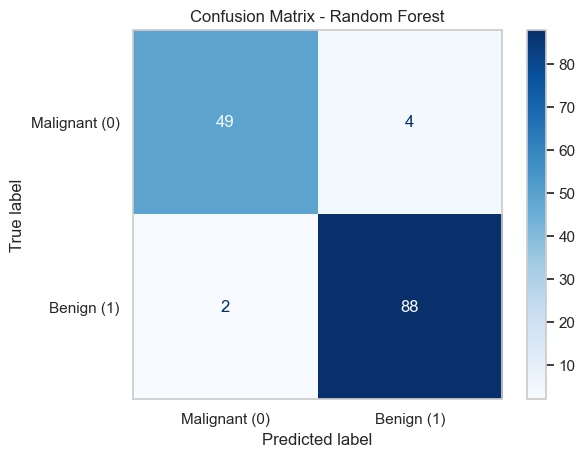


Số bệnh nhân Ác tính bị bỏ sót (False Negative, thực tế 0 -> dự đoán 1): 4


In [7]:
# TODO 6a: Dự đoán trên Test set
y_pred_rf = rf_model.predict(X_test_scaled)

# TODO 6b: In Classification Report
print("=== Classification Report - Random Forest ===")
print(classification_report(y_test, y_pred_rf,
      target_names=["Malignant (0)", "Benign (1)"]))

# Tính riêng Recall & F1 cho lớp 0 (Ác tính)
recall_0 = recall_score(y_test, y_pred_rf, pos_label=0)
f1_0 = f1_score(y_test, y_pred_rf, pos_label=0)
print(f"Recall lớp 0 (Ác tính): {recall_0:.4f}")
print(f"F1-score lớp 0 (Ác tính): {f1_0:.4f}")

# TODO 6c: Vẽ Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=["Malignant (0)", "Benign (1)"])
disp.plot(cmap="Blues")
plt.grid(False)
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Số ca Ác tính bị bỏ sót: thực tế = 0 nhưng dự đoán = 1
false_negative = cm[0, 1]
print(f"\nSố bệnh nhân Ác tính bị bỏ sót (False Negative, thực tế 0 -> dự đoán 1): {false_negative}")

**Đánh giá Task 6 (Business/Medical Insight):**

*(Các con số dưới đây lấy từ output ở ô trên — Random Forest, test 25%, random_state=42.)*

1. **Recall & F1 của lớp Ác tính (0):** Random Forest đạt **Recall = 0.92** và **F1 = 0.94** cho lớp 0 — rất cao, nghĩa là mô hình "bắt" được ~92% số ca ác tính thực sự. Accuracy tổng thể = **0.96**.

2. **Số ca bị bỏ sót (False Negative):** nhìn ô `Thực tế = 0, Dự đoán = 1` trong Confusion Matrix, mô hình bỏ sót **4 ca** ác tính (trên 53 ca ác tính của tập test) — tức chẩn đoán nhầm 4 khối u ác tính thành lành tính.

3. **Nếu là bác sĩ, em sẽ đánh đổi giảm Precision để tăng Recall.** Lý do: trong chẩn đoán ung thư, **False Negative (bỏ sót ca ác tính) nguy hiểm hơn nhiều** False Positive — bỏ sót khiến bệnh nhân mất cơ hội điều trị sớm, có thể tử vong; còn báo động nhầm (lành tính bị nghi ác tính) chỉ dẫn đến xét nghiệm bổ sung, tốn kém nhưng không chết người. Do đó ta chấp nhận hạ ngưỡng quyết định để **tối đa hóa Recall của lớp Ác tính**, dù phải trả giá bằng Precision thấp hơn (nhiều báo động giả hơn).

**Kết luận triển khai:** dù 96% accuracy nghe rất tốt, việc **còn bỏ sót 4 ca ác tính là CHƯA đủ an toàn** cho triển khai lâm sàng thực tế. Hướng cải thiện: **hạ ngưỡng phân loại** (dùng `predict_proba` với ngưỡng < 0.5 cho lớp ác tính), dùng `class_weight="balanced"`, hoặc kết hợp thêm ý kiến chuyên gia — mục tiêu đưa số False Negative về gần 0.